# Mutation-spectrum gradient along single-stranded exposure

This notebook asks whether selected heavy-strand mutation components change from the beginning to the end of the mitochondrial major replication arc. The reference analysis places COX1, COX3, and CytB at the beginning, middle, and end of that arc, respectively ([Molecular Biology and Evolution paper](https://academic.oup.com/mbe/article/42/2/msae261/7998442); [analysis repository](https://github.com/mitoclub/mtdna-192component-mutspec-chordata)).

The x-axis is an illustrative **DssH proxy**, not a measured time for each species. For the three major-arc genes it is calculated as $2(p-OriL)/L$, where $p$ is the midpoint of the human rCRS locus, $OriL=5730$, and $L=16569$ ([DssH method](https://pmc.ncbi.nlm.nih.gov/articles/PMC2943950/)). Coordinates come from NCBI rCRS annotations for [COX1](https://www.ncbi.nlm.nih.gov/gene/4512), [COX3](https://www.ncbi.nlm.nih.gov/gene/4514), and [CytB](https://www.ncbi.nlm.nih.gov/gene/4519/).

ND2 is excluded because it lies on the minor arc under this model; ND6 has no spectrum in the input table.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=Path.cwd()):
    """Find the repository from either its root or notebooks/."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "initial data" / "MutSpecVertebrates12.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.mutation_comparison import (
    orient_substitutions_to_heavy_strand,
    plot_tsss_gradient,
    select_common_species,
    summarize_tsss_slopes,
    validate_matched_spectra,
)

TARGET_CLASS = "Mammalia"
GENES = ("CO1", "CO3", "Cytb")
MUTATIONS_TO_PLOT = ("C>T", "A>G", "G>A", "T>C")
N_BOOT = 5_000
RANDOM_STATE = 20260722
DATA_PATH = ROOT / "initial data" / "MutSpecVertebrates12.csv.gz"
OUTPUT_DIR = ROOT / "output" / "tsss_gradient"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
MTDNA_LENGTH = 16_569
ORIL_START = 5_730
gene_metadata = pd.DataFrame(
    {
        "Gene": ["CO1", "CO3", "Cytb"],
        "display_gene": ["COX1", "COX3", "CytB"],
        "arc_position": ["beginning", "middle", "end"],
        "rCRS_start": [5904, 9207, 14747],
        "rCRS_end": [7445, 9990, 15887],
    }
)
gene_metadata["rCRS_midpoint"] = (
    gene_metadata["rCRS_start"] + gene_metadata["rCRS_end"]
) / 2
gene_metadata["dssh_proxy"] = (
    2 * (gene_metadata["rCRS_midpoint"] - ORIL_START) / MTDNA_LENGTH
)
gene_metadata["plot_label"] = (
    gene_metadata["display_gene"]
    + "\nDssH="
    + gene_metadata["dssh_proxy"].map(lambda value: f"{value:.3f}")
)
gene_metadata.to_csv(OUTPUT_DIR / "gene_tsss_proxy.csv", index=False)
display(gene_metadata.round({"rCRS_midpoint": 1, "dssh_proxy": 3}))

,Gene,display_gene,arc_position,rCRS_start,rCRS_end,rCRS_midpoint,dssh_proxy,plot_label
0,CO1,COX1,beginning,5904,7445,6674.5,0.114,COX1\nDssH=0.114
1,CO3,COX3,middle,9207,9990,9598.5,0.467,COX3\nDssH=0.467
2,Cytb,CytB,end,14747,15887,15317.0,1.157,CytB\nDssH=1.157


In [3]:
spectra = pd.read_csv(DATA_PATH)
mammals = spectra.loc[spectra["Class"].eq(TARGET_CLASS)].copy()
matched_raw, common_species = select_common_species(mammals, GENES)
matched = orient_substitutions_to_heavy_strand(matched_raw)
matched_info = validate_matched_spectra(matched, genes=GENES)

pd.DataFrame({"Species": common_species}).to_csv(
    OUTPUT_DIR / "matched_species_CO1_CO3_Cytb.csv", index=False
)
print(f"Exact all-three-gene intersection: N = {matched_info.n_species} mammals")

Exact all-three-gene intersection: N = 52 mammals


## Descriptive mutation gradients

Faint trajectories connect the same species across genes. Colored points and whiskers are gene means and 95% species-cluster bootstrap intervals. The four panels form two complementary heavy-strand mutation pairs.

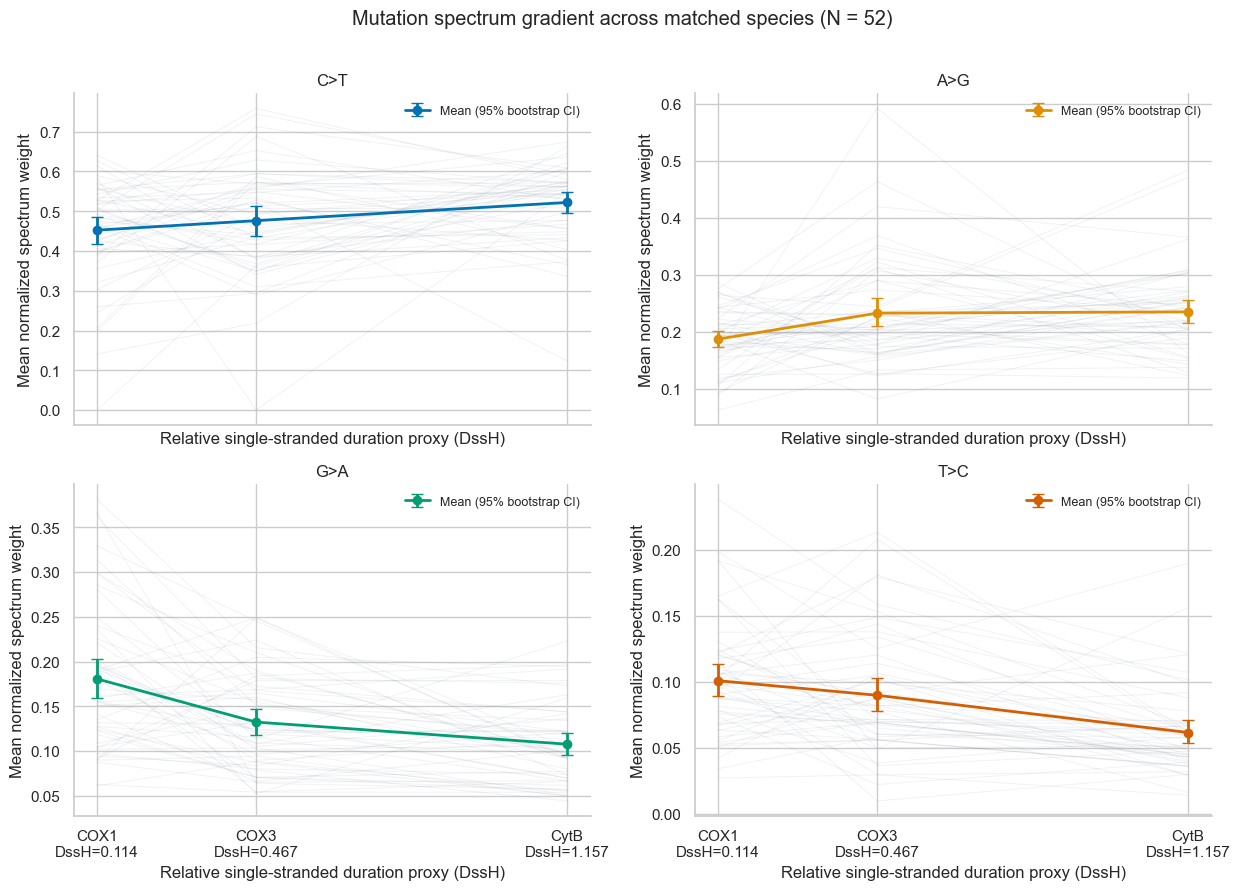

In [4]:
gradient_plot = plot_tsss_gradient(
    matched,
    gene_metadata,
    genes=GENES,
    mutations=MUTATIONS_TO_PLOT,
    tsss_col="dssh_proxy",
    label_col="plot_label",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
gradient_plot.fig.savefig(
    OUTPUT_DIR / "tsss_gradient_selected_mutations.png",
    dpi=300, bbox_inches="tight",
)
gradient_summary = gradient_plot.summary.merge(
    gene_metadata.drop(columns="plot_label"), on=["Gene", "dssh_proxy"],
    validate="many_to_one",
)
gradient_summary.to_csv(
    OUTPUT_DIR / "tsss_gradient_gene_summary.csv", index=False
)
plt.show()

In [5]:
mean_table = (
    gradient_summary.pivot(index="Mut", columns="display_gene", values="estimate")
    .reindex(index=MUTATIONS_TO_PLOT, columns=["COX1", "COX3", "CytB"])
)
mean_table["CytB_minus_COX1"] = mean_table["CytB"] - mean_table["COX1"]
print("Mean normalized spectrum weights and endpoint change")
display(mean_table.round(4))

slope_summary = summarize_tsss_slopes(
    matched,
    gene_metadata,
    genes=GENES,
    mutations=MUTATIONS_TO_PLOT,
    tsss_col="dssh_proxy",
    label_col="display_gene",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
slope_summary.to_csv(OUTPUT_DIR / "tsss_gradient_slope_summary.csv", index=False)
print("Within-species slopes along the DssH proxy")
display(slope_summary.round(4))

Mean normalized spectrum weights and endpoint change


display_gene,COX1,COX3,CytB,CytB_minus_COX1
Mut,,,,
C>T,0.4525,0.4763,0.5221,0.0696
A>G,0.1877,0.2332,0.2354,0.0477
G>A,0.1806,0.1324,0.1077,-0.0729
T>C,0.1007,0.0897,0.0615,-0.0393


Within-species slopes along the DssH proxy


,Mut,n_species,mean_slope_per_proxy_unit,ci_low,ci_high,median_species_slope,fraction_species_positive,confidence
0,C>T,52,0.0667,0.0275,0.1076,0.0538,0.6731,0.95
1,A>G,52,0.0399,0.0183,0.0609,0.0414,0.7115,0.95
2,G>A,52,-0.0652,-0.0849,-0.0462,-0.0546,0.1154,0.95
3,T>C,52,-0.0381,-0.0477,-0.0288,-0.0290,0.1154,0.95


## Interpretation limits

This is an exploratory positional gradient across only three genes. Gene identity, sequence composition, genomic position, and TSSS are confounded; mammals are also phylogenetically non-independent, and spectrum weights sum to one. The plot can reveal a descriptive monotonic pattern, but it cannot by itself establish a causal TSSS effect. Species-specific OriL annotations and a phylogeny-aware compositional model are needed for confirmatory inference.